<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/1_formato_clase/1_formato_clase.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
</table>

In [2]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=4, border=4, fill_color="black", back_color="white"):
    """
    Genera y muestra un código QR para una URL dada en un Jupyter Notebook.
    
    Parámetros:
    - url: La URL para la cual generar el código QR
    - version: Tamaño del QR (1-40, donde 1 es el más pequeño)
    - box_size: Número de píxeles por cada "caja" del QR
    - border: Grosor del borde blanco alrededor del QR (en cajas)
    - fill_color: Color del código QR
    - back_color: Color de fondo del código QR
    
    Retorna:
    - Muestra el código QR directamente en el notebook
    - Retorna el objeto QR generado
    """
    # Configurar el generador de QR
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img

# Ejemplo de uso:
# generar_qr("https://www.ejemplo.com")



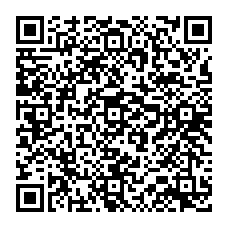

In [3]:
url = "https://colab.research.google.com/github/marco-canas/camino-udea/blob/main/6_razonamiento_geometrico/clase_16_analisis_graficos_y_simulacro_final/clase_16_analisis_graficos.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

## [Vínculo al programa del curso Camino a La Universidad o PIVU:  ](https://github.com/marco-canas/camino-udea/blob/main/0_programa_curso_y_cronograma/programa_curso_pivu_caucasia.ipynb)

# Pregunta 3  

**Enunciado del problema**

**10.3.** Si divido un rollo de cuerda en pedazos de $2$ metros me sobra $1$ metro, si lo divido en pedazos de $3$ metros me me sobran dos metros, y si lo divido en pedazos de $4$ metros me sobran $3$ metros. Si se sabe que la longitud total de la cuerda es de menos de $22$ metros, entonces la longitud total, en metros es:

(a) $19$

(b) $17$

(c) $13$

(d) $11$

---

### Resolución mediante LaTeX

Sea $L$ la longitud total de la cuerda en metros. Del enunciado deducimos el siguiente sistema de congruencias:

$$L \equiv 1 \pmod 2$$

$$L \equiv 2 \pmod 3$$

$$L \equiv 3 \pmod 4$$

Observa que en cada caso, el residuo es exactamente **$1$ unidad menor que el divisor**:

* $L + 1$ es divisible por $2$
* $L + 1$ es divisible por $3$
* $L + 1$ es divisible por $4$

Por lo tanto, $(L + 1)$ debe ser un múltiplo común de $2$, $3$ y $4$. Hallamos el mínimo común múltiplo ($\text{mcm}$):

$$\text{mcm}(2, 3, 4) = 12$$

Esto significa que $L + 1$ debe ser un múltiplo de $12$:

$$L + 1 = 12k \implies L = 12k - 1 \quad \text{para algún entero } k \ge 1$$

Probamos valores para $k$:

* Si $k = 1$: $L = 12(1) - 1 = 11$
* Si $k = 2$: $L = 12(2) - 1 = 23$ (Se descarta, pues $L < 22$)

Dado que las opciones son $19$, $17$, $13$ y $11$, comprobamos $L = 11$:

* $11 \div 2 = 5$ residuo $1$
* $11 \div 3 = 3$ residuo $2$
* $11 \div 4 = 2$ residuo $3$

La respuesta correcta es la **(d) 11**.

---

### Resolución y visualización con Python (`pandas` y `matplotlib`)

Podemos evaluar cada una de las opciones dadas en el problema usando `pandas` y visualizar la verificación de los residuos con `matplotlib`:


   Longitud (L)  Residuo ÷2  Residuo ÷3  Residuo ÷4 ¿Es correcta?
0            19           1           1           3            No
1            17           1           2           1            No
2            13           1           1           1            No
3            11           1           2           3            Sí


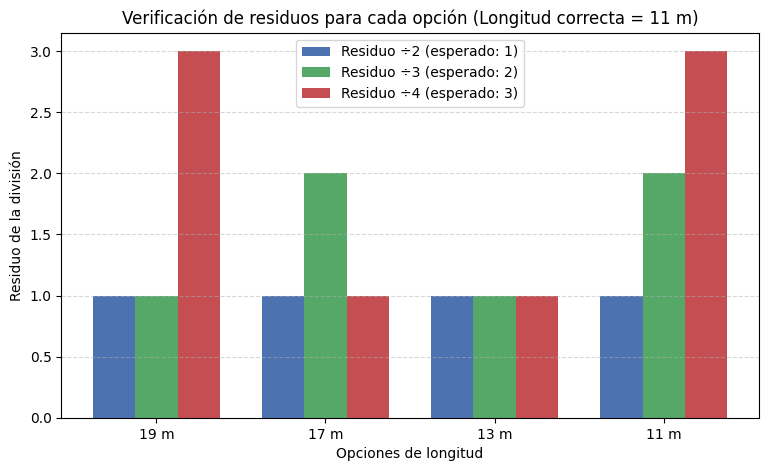

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición de las opciones dadas en la pregunta
opciones = [19, 17, 13, 11]

# 2. Creación del DataFrame con Pandas para verificar los residuos
data = []
for L in opciones:
    r2 = L % 2  # Debe ser 1
    r3 = L % 3  # Debe ser 2
    r4 = L % 4  # Debe ser 3
    cumple = (r2 == 1) and (r3 == 2) and (r4 == 3)
    data.append(
        {
            "Longitud (L)": L,
            "Residuo ÷2": r2,
            "Residuo ÷3": r3,
            "Residuo ÷4": r4,
            "¿Es correcta?": "Sí" if cumple else "No",
        }
    )

df = pd.DataFrame(data)
print(df)

# 3. Gráfica comparativa con Matplotlib
plt.figure(figsize=(9, 5))

x = list(range(len(df)))
width = 0.25

plt.bar(
    [i - width for i in x],
    df["Residuo ÷2"],
    width=width,
    label="Residuo ÷2 (esperado: 1)",
    color="#4C72B0",
)
plt.bar(
    x,
    df["Residuo ÷3"],
    width=width,
    label="Residuo ÷3 (esperado: 2)",
    color="#55A868",
)
plt.bar(
    [i + width for i in x],
    df["Residuo ÷4"],
    width=width,
    label="Residuo ÷4 (esperado: 3)",
    color="#C44E52",
)

plt.xticks(x, [f"{L} m" for L in df["Longitud (L)"]])
plt.xlabel("Opciones de longitud")
plt.ylabel("Residuo de la división")
plt.title(
    "Verificación de residuos para cada opción (Longitud correcta = 11 m)"
)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()



# Pregunta 5 

**Enunciado del problema**

**10.5.** En un salón de clases, un tercio de los niños tiene solamente de a $2$ lápices, otro tercio, tiene solamente de a $3$ lápices y el resto tiene de a $4$ lápices. En total, hay $60$ lápices en el salón. El número de niños en el salón es:

(a) $20$

(b) $25$

(c) $15$

(d) $30$

---

### Resolución mediante LaTeX

Sea $N$ el número total de niños en el salón.

El grupo de niños se divide en tres partes iguales:

1. Un tercio de los niños ($\frac{N}{3}$) tiene $2$ lápices cada uno.
2. Un tercio de los niños ($\frac{N}{3}$) tiene $3$ lápices cada uno.
3. El tercio restante ($1 - \frac{1}{3} - \frac{1}{3} = \frac{1}{3}$, es decir, $\frac{N}{3}$) tiene $4$ lápices cada uno.

Planteamos la ecuación sumando el número total de lápices:

$$\left(\frac{N}{3} \cdot 2\right) + \left(\frac{N}{3} \cdot 3\right) + \left(\frac{N}{3} \cdot 4\right) = 60$$

Factorizamos $\frac{N}{3}$:

$$\frac{N}{3} \cdot (2 + 3 + 4) = 60$$

$$\frac{N}{3} \cdot 9 = 60$$

$$3N = 60$$

$$N = \frac{60}{3}$$

$$N = 20$$

La respuesta correcta es la **(a) 20**.

---

### Resolución y visualización con Python (`pandas` y `matplotlib`)

A continuación, se presenta un código para comprobar el resultado con `pandas` y representar la distribución de lápices con `matplotlib`:

```python
import matplotlib.pyplot as plt
import pandas as pd

# 1. Definición del problema
total_lapices = 60

# Promedio de lápices por niño: (2 + 3 + 4) / 3 = 3
promedio_lapices_por_nino = (2 + 3 + 4) / 3
total_ninos = int(total_lapices / promedio_lapices_por_nino)

# 2. Creación del DataFrame con Pandas
ninos_por_grupo = total_ninos // 3

data = {
    "Grupo de Niños": [
        "1er Tercio (2 lápices)",
        "2do Tercio (3 lápices)",
        "3er Tercio (4 lápices)",
    ],
    "Cantidad de Niños": [
        ninos_por_grupo,
        ninos_por_grupo,
        total_ninos - 2 * ninos_por_grupo,
    ],
    "Lápices por Niño": [2, 3, 4],
}

df = pd.DataFrame(data)
df["Total Lápices"] = df["Cantidad de Niños"] * df["Lápices por Niño"]

print(df)
print(f"\nTotal de niños calculados: {df['Cantidad de Niños'].sum()}")
print(f"Total de lápices verificados: {df['Total Lápices'].sum()}")

# 3. Gráfica con Matplotlib
plt.figure(figsize=(8, 5))
plt.bar(
    df["Grupo de Niños"],
    df["Total Lápices"],
    color=["#4C72B0", "#55A868", "#C44E52"],
)

plt.title(
    f"Distribución de los {total_lapices} lápices entre los {total_ninos} niños"
)
plt.xlabel("Distribución de alumnos")
plt.ylabel("Cantidad total de lápices")
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Mostrar los valores sobre cada barra
for i, v in enumerate(df["Total Lápices"]):
    plt.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.show()

```

## Referentes 

* [stewart precálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ERHIq62I6qFNrmxy6LZb8ZMBci7kUsyNME1nIh9yCBMJ_w?e=0zMSla)  

* [stewart cálculo](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EZgXZjAp8QxPqOAim2hs6LcBNPLGjSHf-xwYnUVYkwa04w?e=RZdTCy)  

* [larson](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ES71ChFeO9ZDhW3TwC5Ijk8BjxUK3Pdqz_fjHxTTFAfIAg?e=VDEjfu)

* [uzcategui](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ETDikm-lVl1Or8XoEo9oyh0BEti9Zs8le-f0D-dBdtZmbA?e=bBsoyQ)

* [Cálculo de Purcell](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/ES60UB4h-QFFqqRQUFmkpWcBIgoLBJeqTfZjNajWNWSeJA?e=9NxjKJ)

* [Recomendación de la UNESCO sobre ciencia abierta](https://unesdoc.unesco.org/ark:/48223/pf0000379949_spa)

* [Geron, Aurelien. Hands on Machine Learning](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/Ecet27yjQzZIlT1Y_Bc2erkBUhbeYuIe6HG8i1FYZRlZww?e=gaOjqk)

* [McKinney, West. Python for data Analysis.](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EVbi5JIeBl9ErbiUnZfGe8YBhNTnZ8sxTK5hjIOPK4UpGw?e=tfkShe)



### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

## [Evaluación luego de alcanzar estos objetivos de aprendizaje]()

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()

# Conjeturas pedagógicas fruto de la aplicación del modelo de aprendizaje invertido y del enfoque hacia la ciencia de datos con python

1. Todo cálculo o resultado debe ser interpretado en una línea markdown del cuaderno Jupyter, inmediatamente después de la enunciación del resultado y después de la presentación de una tabla o gráfico bidimensional, de tal menera que el estudiante explicite la comprensión verbal del resultado y las inferencias o estrategias que este resultado le sugieren.   

## Agradecimientos  

Doy gracias a Dios por la vida de mi Hijo Joseph Cañas Osorio y la madurez que ha alcanzado.

Y a mi esposa Yasmira por su apoyo, orientación y acompañamiento. 

# Desarrollo de competencias en Python y ciencia de datos

## [West McKinney. Python for data Analysis](https://udeaeduco-my.sharepoint.com/:b:/g/personal/marco_canas_udea_edu_co/EVbi5JIeBl9ErbiUnZfGe8YBhNTnZ8sxTK5hjIOPK4UpGw?e=tfkShe)

### CHAPTER 2  
#### Python Language Basics, IPython, and Jupyter Notebooks  



When I wrote the first edition of this book in 2011 and 2012, there were fewer resources available for learning about doing data analysis in Python. This was partially a chicken-and-egg problem; many libraries that we now take for granted, like pandas,
scikit-learn, and statsmodels, were comparatively immature back then. In 2017, there is now a growing literature on data science, data analysis, and machine learning, supplementing the prior works on general-purpose scientific computing geared toward computational scientists, physicists, and professionals in other research fields. There are also excellent books about learning the Python programming language itself and becoming an effective software engineer. As this book is intended as an introductory text in working with data in Python, I feel it is valuable to have a self-contained overview of some of the most important features of Python’s built-in data structures and libraries from the perspective of data manipulation. So, I will only present roughly enough information in this chapter and Chapter 3 to enable you to follow along with the rest of the book.
In my opinion, it is not necessary to become proficient at building good software in Python to be able to productively do data analysis. I encourage you to use the IPython shell and Jupyter notebooks to experiment with the code examples and to
explore the documentation for the various types, functions, and methods. While I’ve made best efforts to present the book material in an incremental form, you may occasionally encounter things that have not yet been fully introduced.
Much of this book focuses on table-based analytics and data preparation tools for working with large datasets. In order to use those tools you must often first do some munging to corral messy data into a more nicely tabular (or structured) form. Fortu‐
nately, Python is an ideal language for rapidly whipping your data into shape. The greater your facility with Python the language, the easier it will be for you to prepare new datasets for analysis. Some of the tools in this book are best explored from a live IPython or Jupyter session. Once you learn how to start up IPython and Jupyter, I recommend that you follow along with the examples so you can experiment and try different things. As with any keyboard-driven console-like environment, developing muscle-memory for the common commands is also part of the learning curve. There are introductory Python concepts that this chapter does not cover, like classes and object-oriented programming, which you may find useful in your foray into data analysis in Python. To deepen your Python language knowledge, I recommend that you supplement this chapter with the official Python tutorial and potentially one of the many excellent books on general-purpose Python programming. Some recommendations to get you started include:  

* Python Cookbook, Third Edition, by David Beazley and Brian K. Jones (O’Reilly)
* Fluent Python by Luciano Ramalho (O’Reilly)
* Effective Python by Brett Slatkin (Pearson)

# [Geron. Hand on Neuronal Networks]()

Página 279 del libro. Segunda edición.

## Chapter 10. Introduction to Artificial Neural Networks with Keras  

### Implementing MLPs with Keras

Keras is a high-level Deep Learning API that allows you to easily build, train, evaluate, and execute all sorts of neural networks. Its documentation (or specification) is available at https://keras.io/. The reference implementation, also called Keras, was developed by François Chollet as part of a research project and was released as an open source project in
March 2015. It quickly gained popularity, owing to its ease of use, flexibility, and beautiful design. To perform the heavy computations required by neural networks, this reference implementation relies on a computation backend. At present, you can choose from three popular open source Deep Learning libraries: TensorFlow, Microsoft Cognitive Toolkit(CNTK), and Theano. Therefore, to avoid any confusion, we will refer to this reference implementation as multibackend Keras. Since late 2016, other implementations have been released. You can now run Keras on Apache MXNet, Apple’s Core ML, JavaScript or TypeScript (to run Keras code in a web browser), and PlaidML (which can run on all sorts of GPU devices, not just Nvidia). Moreover, TensorFlow itself now comes bundled with its own Keras implementation, tf.keras. It only supports TensorFlow as the backend, but it has the advantage of offering some very useful extra features (see Figure 10-10): for example, it supports TensorFlow’s Data API, which makes it easy to load and preprocess data efficiently. For this reason, we will use tf.keras in this book. However, in this chapter we will not use any of the TensorFlow-specific features, so the code should run fine on other Keras implementations as well (at least in Python), with only minor modifications, such as changing the imports.

<img src = 'https://github.com/marco-canas/7_didactica_ciencia_datos/blob/main/referentes/geron/part_2/c_10/images/fig_10_10.png?raw=true'>

The most popular Deep Learning library, after Keras and TensorFlow, is
Facebook’s PyTorch library. The good news is that its API is quite similar
to Keras’s (in part because both APIs were inspired by Scikit-Learn and
Chainer), so once you know Keras, it is not difficult to switch to PyTorch, if
you ever want to. PyTorch’s popularity grew exponentially in 2018, largely
thanks to its simplicity and excellent documentation, which were not
TensorFlow 1.x’s main strengths. However, TensorFlow 2 is arguably just
as simple as PyTorch, as it has adopted Keras as its official high-level API
and its developers have greatly simplified and cleaned up the rest of the
API. The documentation has also been completely reorganized, and it is
much easier to find what you need now. Similarly, PyTorch’s main
weaknesses (e.g., limited portability and no computation graph analysis)
have been largely addressed in PyTorch 1.0. Healthy competition is
beneficial to everyone.
All right, it’s time to code! As tf.keras is bundled with TensorFlow, let’s
start by installing TensorFlow.
Installing TensorFlow 2
Assuming you installed Jupyter and Scikit-Learn by following the
installation instructions in Chapter 2, use pip to install TensorFlow. If you
created an isolated environment using virtualenv, you first need to activate
it:
$ cd $ML_PATH # Your ML working directory (e.g., $HOME/ml)
$ source my_env/bin/activate # on Linux or macOS
$ .\my_env\Scripts\activate # on Windows
Next, install TensorFlow 2 (if you are not using a virtualenv, you will need
administrator rights, or to add the --user option):
$ python3 -m pip install --upgrade tensorflow

### NOTE

For GPU support, at the time of this writing you need to install tensorflow-gpu instead of tensorflow, but the TensorFlow team is working on having a single library that will
support both CPU-only and GPU-equipped systems. You will still need to install extra
libraries for GPU support (see https://tensorflow.org/install for more details). We will
look at GPUs in more depth in Chapter 19.
To test your installation, open a Python shell or a Jupyter notebook, then
import TensorFlow and tf.keras and print their versions:

In [1]:
import tensorflow as tf 